In [4]:
print("# EXP NO: 6\nName: Piriyadharshini N\nRoll No: 24BAD086\nLSTM for Sentiment Analysis")

import numpy as np
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load dataset from Hugging Face
dataset = load_dataset("stanfordnlp/imdb")

# Get train and test data
X_train = dataset["train"]["text"]
y_train = np.array(dataset["train"]["label"])

X_test = dataset["test"]["text"]
y_test = np.array(dataset["test"]["label"])

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("Positive samples:", np.sum(y_train == 1))
print("Negative samples:", np.sum(y_train == 0))

# Tokenization
vocab_size = 10000
max_length = 200

tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

# EXP NO: 6
Name: Piriyadharshini N
Roll No: 24BAD086
LSTM for Sentiment Analysis
Training samples: 25000
Testing samples: 25000
Positive samples: 12500
Negative samples: 12500
Training shape: (25000, 200)
Testing shape: (25000, 200)


In [5]:
# PART B: Embedding Generation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

embedding_dim = 64

embedding_model = Sequential([
    Embedding(vocab_size, embedding_dim)
])

embedding_output = embedding_model(X_train_pad[:1])

print("Vocabulary size:", vocab_size)
print("Embedding dimension:", embedding_dim)
print("Embedding shape:", embedding_output.shape)

Vocabulary size: 10000
Embedding dimension: 64
Embedding shape: (1, 200, 64)


In [6]:
# PART C: Implementing LSTM Model

from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    Embedding(vocab_size, embedding_dim),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 151ms/step - accuracy: 0.7804 - loss: 0.4553 - val_accuracy: 0.9080 - val_loss: 0.2641
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 142ms/step - accuracy: 0.9030 - loss: 0.2486 - val_accuracy: 0.7452 - val_loss: 0.7075
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 145ms/step - accuracy: 0.9304 - loss: 0.1841 - val_accuracy: 0.8696 - val_loss: 0.3038
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.9521 - loss: 0.1358 - val_accuracy: 0.7462 - val_loss: 0.7142
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step - accuracy: 0.9688 - loss: 0.0937 - val_accuracy: 0.8144 - val_loss: 0.6923
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.8555 - loss: 0.5157

Test Loss: 0.5157397389411926
Test Accuracy: 0.8554800152778625
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step

Accuracy : 0.85548
Precision: 0.8695218295218295
Recall   : 0.83648
F1 Score : 0.8526809378185525

Confusion Matrix:
[[10931  1569]
 [ 2044 10456]]


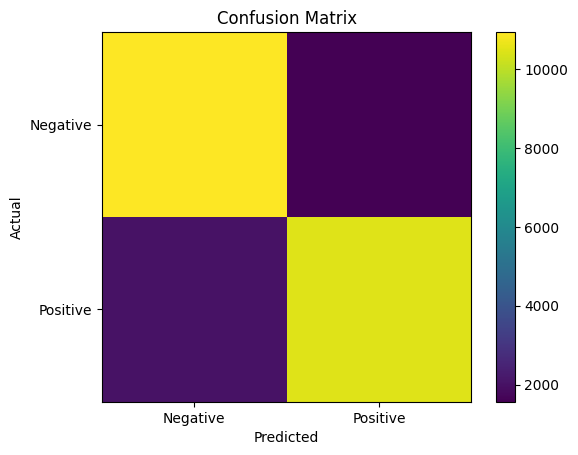

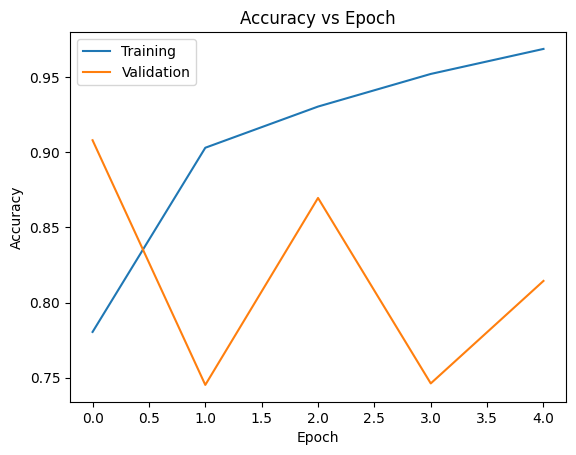

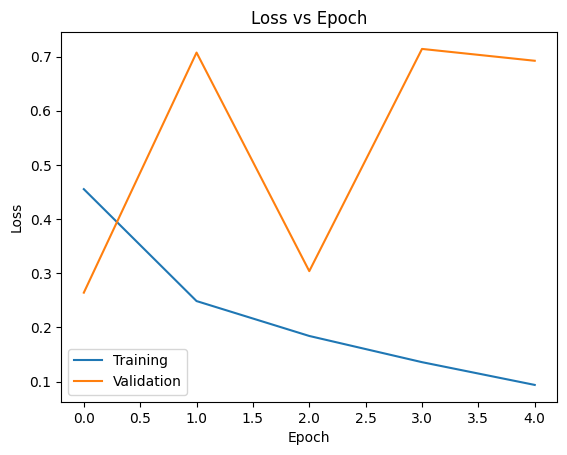

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Predicted Sentiment: Positive


In [7]:
# PART D: Training and Prediction

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# Train model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

# Predictions
y_prob = model.predict(X_test_pad)
y_pred = (y_prob >= 0.5).astype(int).flatten()

# Metrics
print("\nAccuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

plt.show()

# Accuracy graph
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])
plt.show()

# Loss graph
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Validation"])
plt.show()

# Sample prediction
sample = ["I really enjoyed this movie. It was excellent!"]

sample_seq = tokenizer.texts_to_sequences(sample)
sample_pad = pad_sequences(sample_seq, maxlen=max_length)

prediction = model.predict(sample_pad)

if prediction[0][0] >= 0.5:
    print("\nPredicted Sentiment: Positive")
else:
    print("\nPredicted Sentiment: Negative")